<a href="https://colab.research.google.com/github/RAseng77/computer_vision_study/blob/main/%EC%BB%B4%ED%93%A8%ED%84%B0%EA%B8%B0%EB%B3%B8_%EA%B8%B0%EC%B4%88/%EC%82%B0%ED%83%80%ED%81%B4%EB%A1%9C%EC%8A%A4vs%EC%9D%BC%EB%B0%98%EC%9D%B8_%EB%B6%84%EB%A5%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving 산타.zip to 산타.zip


In [2]:
!unzip "산타.zip" -d /content/santa_dataset

Archive:  산타.zip
  inflating: /content/santa_dataset/4/test/normal/590.not-a-santa.jpg  
  inflating: /content/santa_dataset/4/test/normal/605.not-a-santa.jpg  
  inflating: /content/santa_dataset/4/test/normal/556.not-a-santa.jpg  
  inflating: /content/santa_dataset/4/test/normal/588.not-a-santa.jpg  
  inflating: /content/santa_dataset/4/test/normal/576.not-a-santa.jpg  
  inflating: /content/santa_dataset/4/test/normal/610.not-a-santa.jpg  
  inflating: /content/santa_dataset/4/test/normal/567.not-a-santa.jpg  
  inflating: /content/santa_dataset/4/test/normal/589.not-a-santa.jpg  
  inflating: /content/santa_dataset/4/test/normal/570.not-a-santa.jpg  
  inflating: /content/santa_dataset/4/test/normal/.DS_Store  
  inflating: /content/santa_dataset/4/test/normal/609.not-a-santa.jpg  
  inflating: /content/santa_dataset/4/test/normal/581.not-a-santa.jpg  
  inflating: /content/santa_dataset/4/test/normal/552.not-a-santa.jpg  
  inflating: /content/santa_dataset/4/test/normal/611.not

In [18]:
!ls /content/santa_dataset/4/

test  train  val


In [45]:
import os
import glob
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Dataset

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
device

device(type='cuda')

In [6]:
print('Device: ',device)
print('Count of using GPUs:', torch.cuda.device_count())

Device:  cuda
Count of using GPUs: 1


In [7]:
# 이미지를 출력하는 함수
def display_images(image_paths, title, max_images=4):
  """지정된 경로의 이미지를 최대 4개까지 출력합니다."""
  plt.figure(figsize=(12, 3))
  for i, image_path in enumerate(image_paths[:max_images]):
    img = plt.imread(image_path)
    plt.subplot(1, max_images, i+1)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
  plt.show()

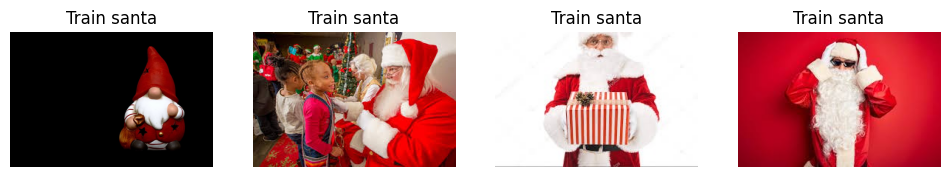

Train santa 총 이미지 수: 446


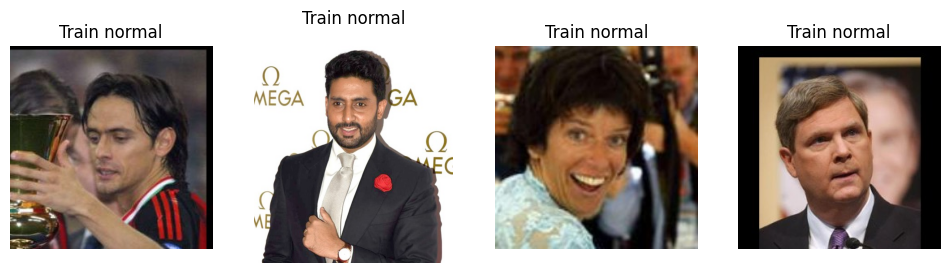

Train normal 총 이미지 수: 449


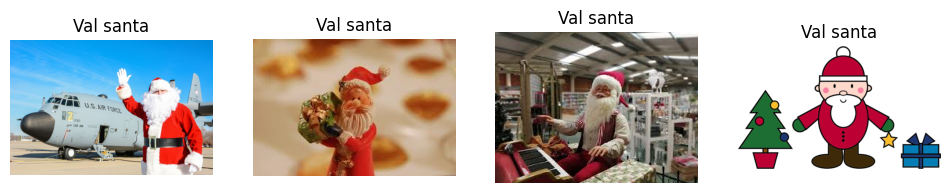

Val santa 총 이미지 수: 133


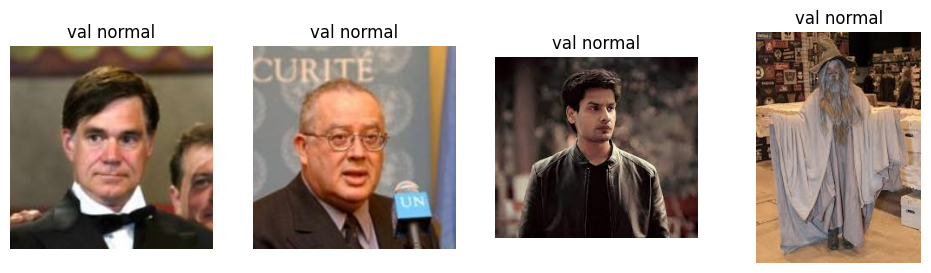

val normal 총 이미지 수: 134


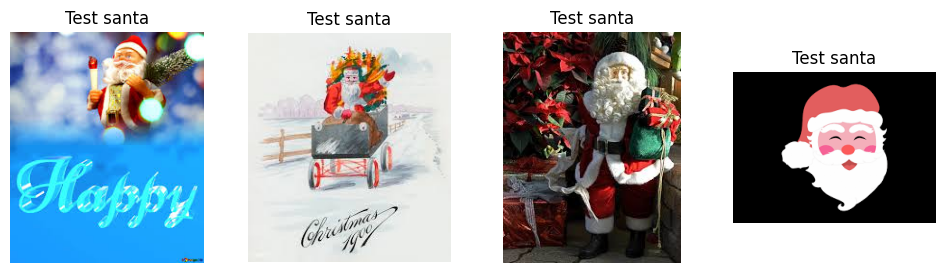

Test santa 총 이미지 수: 36


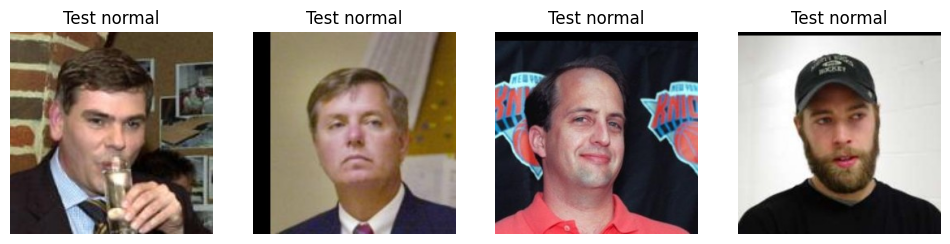

Test normal 총 이미지 수: 32


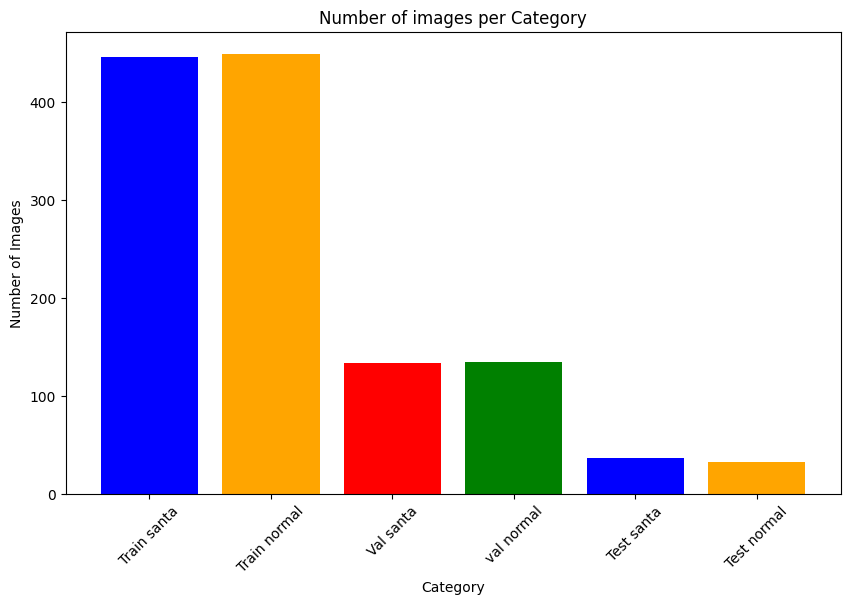

In [17]:
# 이미지와 바 그래프 출력
categories = ['Train santa', 'Train normal', 'Val santa', 'val normal', 'Test santa', 'Test normal']

for category in categories:
  image_paths = glob.glob(f'/content/santa_dataset/4/{category.lower().replace(" ","/")}/*')
  display_images(image_paths, category)
  print(f"{category} 총 이미지 수: {len(image_paths)}")

# 바 그래프 생성
plt.figure(figsize=(10, 6))
plt.bar(categories, [len(glob.glob(f'/content/santa_dataset/4/{category.lower().replace(" ","/")}/*')) for category in categories], color=['blue','orange','red','green'])
plt.title('Number of images per Category')
plt.xlabel('Category')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.show()

In [19]:
# 데이터 전처리 정의
transform = transforms.Compose([
    transforms.Resize((224, 224)), # 이미지 크기 조정
    transforms.RandomHorizontalFlip(30), # 이미지를 최대 30도까지 무작위로 회전
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_path = '/content/santa_dataset/4/train'
val_path = '/content/santa_dataset/4/val'
# 데이터셋 로드 및 데이터 로더 생성
train_dataset = ImageFolder(train_path, transform=transform)
val_dataset = ImageFolder(val_path, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

In [27]:
class VGG19(nn.Module):
  def __init__(self, num_classes=1000):
    super(VGG19, self).__init__()
    self.features = nn.Sequential(
        # Conv Block 1
        nn.Conv2d(3, 64, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(64, 64, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),
        # Conv Block 2
        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(128, 128, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),
        # Conv Block 3
        nn.Conv2d(128, 256, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(256, 256, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(256, 256, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(256, 256, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),
        # Conv Block 4
        nn.Conv2d(256, 512, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(512, 512, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(512, 512, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(512, 512, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),
        # Conv Block 5
        nn.Conv2d(512, 512, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(512, 512, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(512, 512, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(512, 512, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),
    )

    self.classifier = nn.Sequential(
        nn.Linear(512 * 7 * 7, 4096),
        nn.ReLU(inplace=True),
        nn.Dropout(),
        nn.Linear(4096, 4096),
        nn.ReLU(inplace=True),
        nn.Dropout(),
        nn.Linear(4096, num_classes),
    )

  def forward(self, x):
    x = self.features(x)
    x = torch.flatten(x, 1)
    x = self.classifier(x)
    return x

In [28]:
# 1. 사전 학습된 VGG19 모델 불러오기
pretrained_vgg19 = models.vgg19(pretrained=True)
# 2. 내가 새로 정의한 VGG19 모델 인스턴스 생성
net = VGG19(num_classes=1000) # 이진분류 문제로 쓸거라면 classifier만 수정 예정

# 3. 사전 학습된 모델(features) 가중치 키(레이어 이름) 추출
pretrained_keys = set(pretrained_vgg19.features.state_dict().keys())
# 4. 커스텀 모델의 features에 가중치 복사
result = net.features.load_state_dict(pretrained_vgg19.features.state_dict(), strict=False)

# 5. 복사 후 커스텀 모델의 features 부분 키 추출
custom_keys = set(net.features.state_dict().keys())
# 6. 성공적으로 복사된 키 확인
successfully_copied_keys = pretrained_keys.intersection(custom_keys)
# 7. 커스텀에 있는데 pretrained에 없는 키 (누락)
missing_keys = custom_keys - pretrained_keys
# 8. pretrained에는 있는데 커스텀에는 없는 키 (예상치 못한)
unexapected_keys = pretrained_keys - custom_keys

print("성공적으로 복사된 가중치:", successfully_copied_keys)
print("커스텀 모델에는 있지만 사전 학습된 모델에는 없는 가중치 (누락):", result.missing_keys)
print("사전 학습된 모델에는 있지만 커스텀 모델에는 없는 가중치 (예상치 못한):", result.unexpected_keys)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


성공적으로 복사된 가중치: {'28.bias', '0.weight', '28.weight', '0.bias', '2.bias', '21.bias', '12.bias', '16.bias', '25.bias', '5.bias', '16.weight', '30.weight', '12.weight', '32.bias', '32.weight', '23.weight', '25.weight', '30.bias', '2.weight', '10.weight', '19.bias', '21.weight', '23.bias', '34.bias', '14.weight', '10.bias', '34.weight', '7.bias', '5.weight', '19.weight', '14.bias', '7.weight'}
커스텀 모델에는 있지만 사전 학습된 모델에는 없는 가중치 (누락): []
사전 학습된 모델에는 있지만 커스텀 모델에는 없는 가중치 (예상치 못한): []


In [29]:
# 모델의 모든 파라미터를 고정
for param in net.features.parameters():
  param.requires_grad = False

In [30]:
net

VGG19(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), pa

In [31]:
# classifier 부분의 가중치는 재학습을 위해 새로 정의
net.classifier[6] = nn.Linear(4096, 1)

for param in net.classifier.parameters():
  param.requires_grad = True

In [32]:
net = net.to(device)

In [33]:
print(net)

VGG19(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), pa

In [34]:
# 손실 함수
criterion = nn.BCEWithLogitsLoss()

In [41]:
def validate_model(net, val_loader, criterion):
  net.eval() # 모델을 평가 모드로 설정
  val_loss = 0.0
  correct = 0
  total = 0
  with torch.no_grad():
    for inputs, labels in val_loader:
      inputs, labels = inputs.to(device), labels.to(device)
      labels = labels.float().unsqueeze(1) # 레이블을 float으로 바꾸고 (N,) -> (N,1) 형태 맞춤
      outputs = net(inputs)
      val_loss += criterion(outputs, labels).item()
      predicted = torch.sigmoid(outputs) > 0.5
      total += labels.size(0)
      correct += (predicted == labels).sum().item()


  val_loss /= len(val_loader)
  val_accuracy = 100 * correct / total
  return val_loss, val_accuracy

In [39]:
import torch.optim as optim

def train_model(optimizer_name, net, train_loader, val_loader, criterion, num_epochs=10):
  # optimizer 설정
  if optimizer_name == 'SGD':
    optimizer = optim.SGD(net.parameters(), lr=0.00001, momentum=0.9)
  elif optimizer_name == 'Adam':
    optimizer = optim.Adam(net.parameters(), lr=0.00001, betas=(0.9, 0.999))
  elif optimizer_name == 'RAdam':
    optimizer = optim.RAdam(net.parameters(), lr=0.00001, betas=(0.9, 0.999))
  else:
    raise ValueError(f"Unsupported optimizer: {optimizer_name}")

  # 학습/검증 손실과 검증 정확도를 저장할 리스트
  train_losses = []
  val_losses = []
  val_accuracies = []

  for epoch in range(num_epochs):
    net.train() # 모델을 학습 모드로 설정
    running_loss = 0.0
    for inputs, labels in train_loader:
      inputs, labels = inputs.to(device), labels.to(device)
      labels = labels.float().unsqueeze(1) # 레이블을 float으로 바꾸고 (N,) -> (N,1) 형태 맞춤
      optimizer.zero_grad()
      outputs = net(inputs)
      loss = criterion(outputs, labels) # 손실 계산
      loss.backward()
      optimizer.step()
      running_loss += loss.item()

    # 매 에포크마다 평균 학습 손실 계산
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # 검증 손실 및 정확도 계산
    val_loss, val_accuracy = validate_model(net, val_loader, criterion)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f'[{optimizer_name}] Epoch {epoch + 1}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}, Validation Accuracy: {val_accuracy:.2f}%')


  return train_losses, val_losses, val_accuracies


In [42]:
train_losses_RAdam, val_losses_RAdam, val_accuracies_RAdam = train_model('RAdam', net, train_loader, val_loader, criterion)

[RAdam] Epoch 1, Train Loss: 0.473661, Val Loss: 0.377727, Validation Accuracy: 90.64%
[RAdam] Epoch 2, Train Loss: 0.301930, Val Loss: 0.236090, Validation Accuracy: 91.01%
[RAdam] Epoch 3, Train Loss: 0.179345, Val Loss: 0.170659, Validation Accuracy: 93.63%
[RAdam] Epoch 4, Train Loss: 0.103553, Val Loss: 0.138804, Validation Accuracy: 94.76%
[RAdam] Epoch 5, Train Loss: 0.063002, Val Loss: 0.118231, Validation Accuracy: 95.88%
[RAdam] Epoch 6, Train Loss: 0.034933, Val Loss: 0.112998, Validation Accuracy: 95.51%
[RAdam] Epoch 7, Train Loss: 0.020105, Val Loss: 0.103413, Validation Accuracy: 95.51%
[RAdam] Epoch 8, Train Loss: 0.011899, Val Loss: 0.108690, Validation Accuracy: 95.51%
[RAdam] Epoch 9, Train Loss: 0.007885, Val Loss: 0.103234, Validation Accuracy: 95.51%
[RAdam] Epoch 10, Train Loss: 0.005276, Val Loss: 0.107553, Validation Accuracy: 95.51%


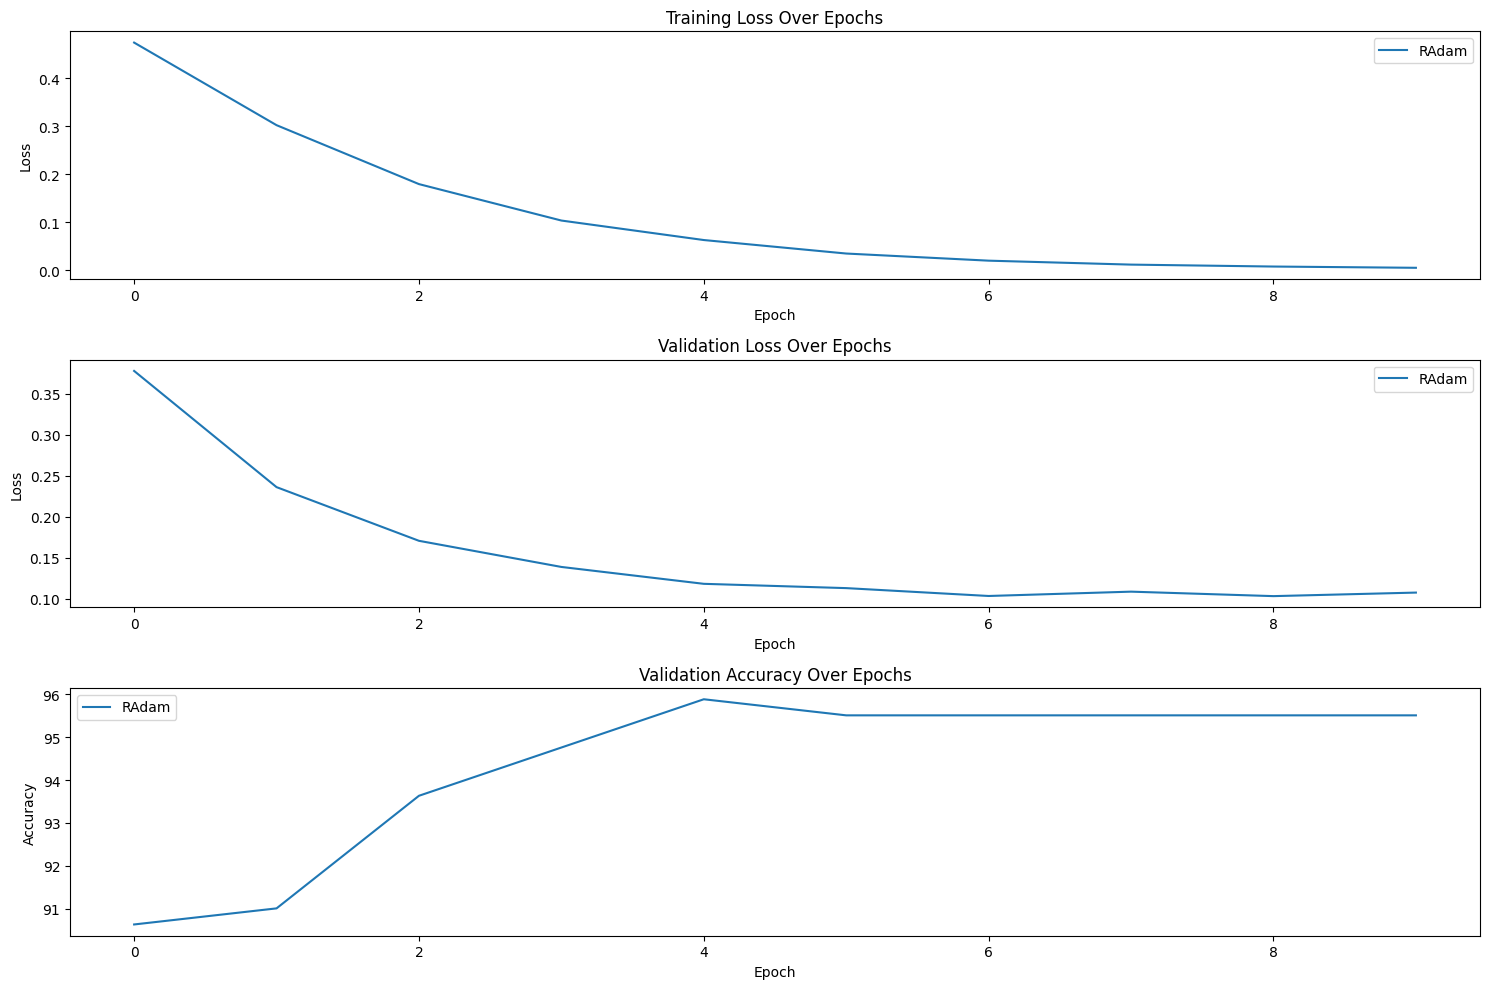

In [43]:
# 학습 손실과 검증 정확도 그래프 그리기
plt.figure(figsize=(15, 10))

# 학습 손실 그래프
plt.subplot(3, 1, 1)
plt.plot(train_losses_RAdam, label='RAdam')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()

# 검증 손실 그래프
plt.subplot(3, 1, 2)
plt.plot(val_losses_RAdam, label='RAdam')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss Over Epochs')
plt.legend()

# 검증 정확도 그래프
plt.subplot(3, 1, 3)
plt.plot(val_accuracies_RAdam, label='RAdam')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Over Epochs')
plt.legend()

plt.tight_layout()
plt.show()

In [44]:
# Image load 및 tensor로 변환
def load_and_transform_image(image_path, transform):
  image = Image.open(image_path).convert('RGB')
  return transform(image).unsqueeze(0).to(device) # 이미지를 모델에 맞게 변환하고 배치 차원 추가

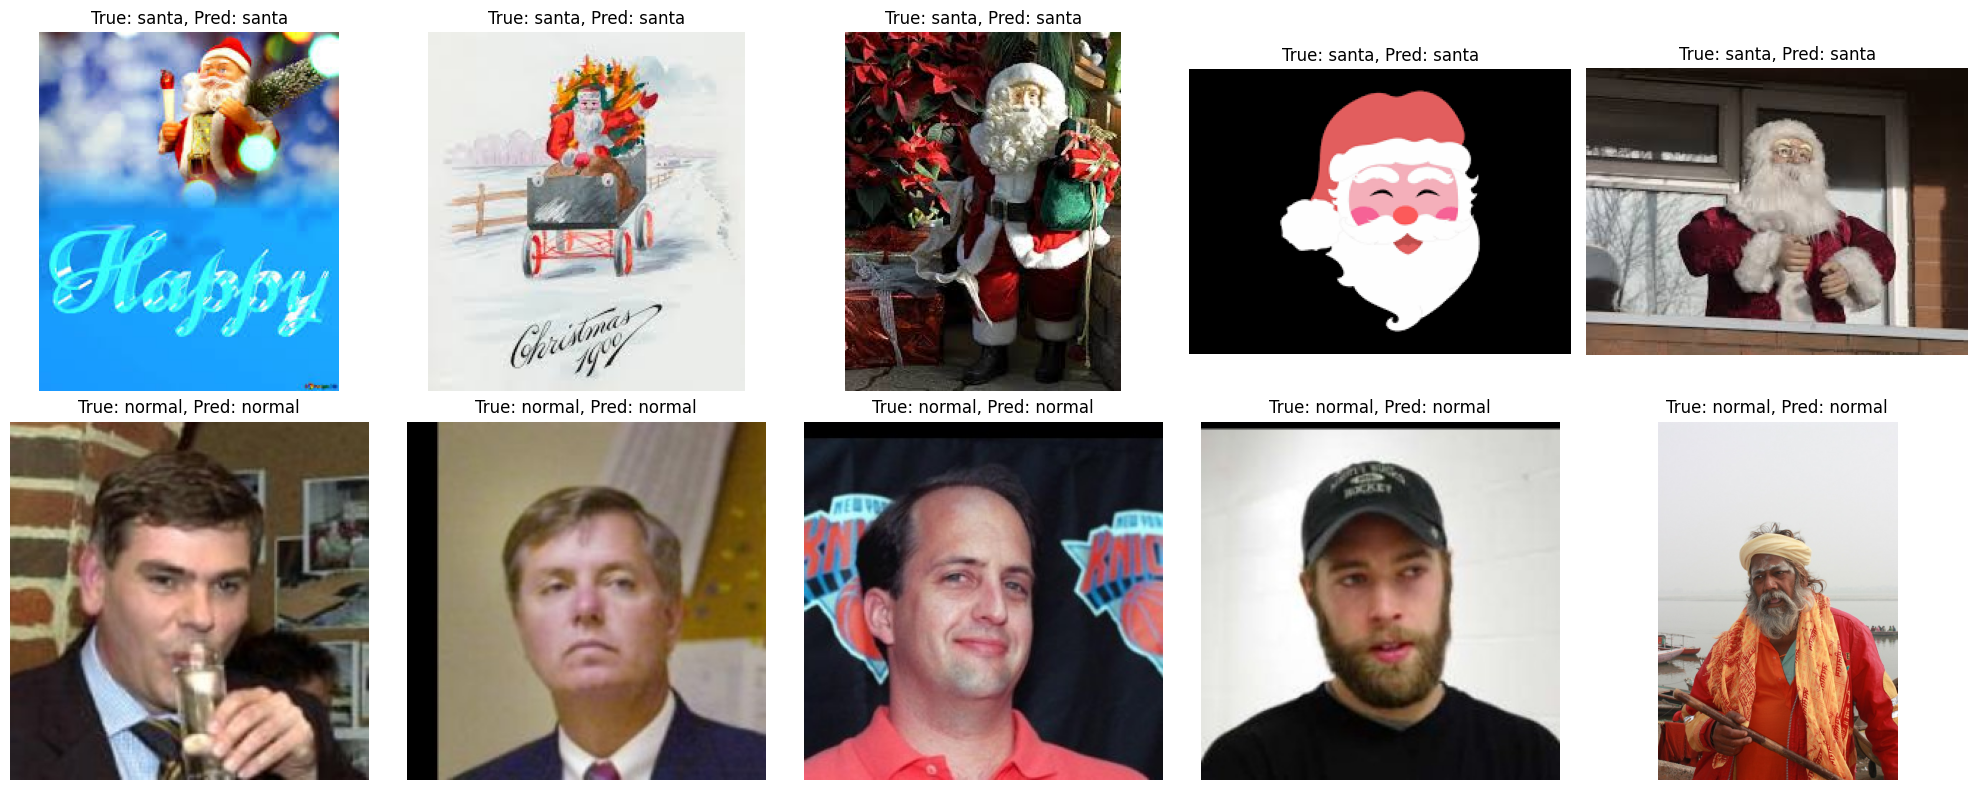

In [46]:
# 클래스별 폴더 경로
class_folders = {
    'santa': '/content/santa_dataset/4/test/santa',
    'normal': '/content/santa_dataset/4/test/normal'
}

plt.figure(figsize=(20, 8))
# subplor 인덱스를 위한 카운터 클래스별 폴더 경로
counter = 1

# 각 클래스별로 5장의 이미지 추론 및 시각화
for class_name, folder_path in class_folders.items():
  # 해당 클래스의 이미지 경로 가져오기
  image_paths = glob.glob(os.path.join(folder_path, '*'))
  selected_paths = image_paths[:5] # 첫 5장 선택

  for image_path in selected_paths:
    image = load_and_transform_image(image_path, transform)

    net.eval() # 모델을 평가 모드로 설정
    # 모델을 사용한 추론
    with torch.no_grad():
      outputs = net(image)
      # 시그모이드 함수 적용하여 확률 얻기
      probs = torch.sigmoid(outputs).item()
      prediction = 'santa' if probs >= 0.5 else 'normal'

    # 결과 시각화
    plt.subplot(2, 5, counter)
    plt.imshow(Image.open(image_path))
    plt.title(f'True: {class_name}, Pred: {prediction}')
    plt.axis('off')

    counter += 1 # subplot 인덱스 업데이트

plt.tight_layout()
plt.show()